# BIND2 Thermo — test-set field check

Companion to `analysis_2d.ipynb` for the **joint mass + gas-thermodynamics** run
(`--stars_two_head --predict_thermo`, `out_ch = 8` = 4 mass-head + 4 thermo).
It samples DMO→hydro on a fixed test subset and asks *how well the generated
fields match truth*, with emphasis on the four new thermo channels
(`compton_y`, `temperature`, `entropy`, `pressure`).

Physical output order is `[DM_hydro, Gas, Stars, compton_y, temperature, entropy, pressure]`.
Thermo fields are strictly positive with huge dynamic range, so accuracy is
measured in **dex** (`log10(gen/truth)`), matching the test-suite metric — and
they are evaluated **per halo cutout**, never composited into a full box.

In [56]:
import sys, os
sys.path.insert(0, '/mnt/home/mlee1/vdm_bind2')
os.environ.setdefault('CUDA_VISIBLE_DEVICES', '0')

import re
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from bind.data import load_file_list, AstroDataset, NormStats, THERMO_KEYS, N_THERMO
from bind.train import FlowMatchingLit
from bind.metrics import power_spectrum_2d, radial_profile, CHANNEL_NAMES
from bind.inference.pipeline import _denormalize_to_physical

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})

MASS_NAMES   = list(CHANNEL_NAMES)          # ['DM_hydro', 'Gas', 'Stars']
THERMO_NAMES = list(THERMO_KEYS)            # compton_y, temperature, entropy, pressure
THERMO_UNITS = ['dimensionless', 'K', 'keV cm$^2$', 'Pa']
ALL_NAMES    = MASS_NAMES + THERMO_NAMES    # physical channel order (7)
print(f'Device: {device} | {N_THERMO} thermo channels: {THERMO_NAMES}')

Device: cuda | 4 thermo channels: ['compton_y', 'temperature', 'entropy', 'pressure']


In [57]:
# ── Configuration ────────────────────────────────
DATA_ROOT = '/mnt/home/mlee1/ceph/train_data_rotated2_128_cpu'
RUNS_DIR  = Path('/mnt/home/mlee1/ceph/fm_runs')
RUN_NAME  = 'fm_thermo'        # joint mass + 4 gas-thermo emulator (out_ch = 8)
RUN_DIR   = RUNS_DIR / RUN_NAME
CKPT_NAME = 'last.ckpt'        # 'last.ckpt' tracks the live run; or 'epoch00X-....ckpt'

BOX_SIZE  = 6.25               # Mpc/h per halo cutout
N_PIX     = 128
PIX_SIZE  = BOX_SIZE / N_PIX   # Mpc/h per pixel

N_TEST     = 2048               # test patches to evaluate
N_STEPS    = 20                # ODE steps for FM sampling
BATCH_SIZE = 64
N_WORKERS  = 8
SEED       = 42

# Fixed test subset, keeping only patches that carry all 4 thermo maps (a
# minority of no-lowmass sims lack them; AstroDataset would resample those,
# but pre-filtering keeps file order == array order so halo_mass stays aligned).
rng = np.random.RandomState(SEED)
all_test = load_file_list(DATA_ROOT, 'test')
test_files, halo_mass = [], []
for i in rng.permutation(len(all_test)):
    d = np.load(all_test[i])
    if all(k in d.files for k in THERMO_KEYS):
        test_files.append(all_test[i])
        halo_mass.append(float(d['halo_mass']) if 'halo_mass' in d.files else np.nan)
    if len(test_files) >= N_TEST:
        break
halo_mass = np.asarray(halo_mass)
print(f'Test patches: {len(test_files)} (thermo-bearing, from {len(all_test)} total)')
print(f'halo_mass range: [{np.nanmin(halo_mass):.2e}, {np.nanmax(halo_mass):.2e}]')

Test patches: 2048 (thermo-bearing, from 42720 total)
halo_mass range: [1.00e+13, 7.36e+14]


In [58]:
# ── Model loading & inference ────────────────────
def _ckpt_epoch(ckpt):
    m = re.search(r'epoch(\d+)', Path(ckpt).name)
    if m:
        return int(m.group(1))
    try:                                   # 'last.ckpt' carries epoch in the dict
        return torch.load(ckpt, map_location='cpu', weights_only=False).get('epoch', '?')
    except Exception:
        return '?'


def load_run(run_dir, ckpt_name='last.ckpt'):
    run_dir = Path(run_dir)
    ckpt = run_dir / 'checkpoints' / ckpt_name
    if not ckpt.exists():
        raise FileNotFoundError(f'Missing checkpoint: {ckpt}')
    model = FlowMatchingLit.load_from_checkpoint(str(ckpt), map_location=device)
    model.eval().to(device)                # raw weights, no EMA (matches analysis_2d)
    ns = NormStats.load(run_dir / 'norm_stats.npz')
    assert ns.predict_thermo, 'norm_stats has no thermo stats — wrong run?'
    return model, ns, _ckpt_epoch(ckpt)


@torch.no_grad()
def generate_predictions(model, ns, files, batch_size=64, n_steps=20, n_workers=8):
    """Sample DMO→hydro; return physical-space (real, gen, params).

    real/gen are (N, 3 + N_THERMO, H, W): [DM_hydro, Gas, Stars, compton_y,
    temperature, entropy, pressure] via _denormalize_to_physical for both.
    """
    ds = AstroDataset(files, ns)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False,
                        num_workers=n_workers, pin_memory=True,
                        persistent_workers=(n_workers > 0))
    real, gen, prm = [], [], []
    for batch in tqdm(loader, desc='sampling', leave=False):
        cond   = batch['condition'].to(device)
        ls     = batch['large_scale'].to(device)
        params = batch['params'].to(device)
        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            g = model.fm.sample(cond, ls, params, n_steps=n_steps)
        real.append(_denormalize_to_physical(batch['target'].numpy().copy(), ns))
        gen.append(_denormalize_to_physical(g.float().cpu().numpy(), ns))
        prm.append(batch['params'].numpy())
    return np.concatenate(real), np.concatenate(gen), np.concatenate(prm)

In [59]:
model, ns, epoch = load_run(RUN_DIR, CKPT_NAME)
print(f'Loaded {RUN_NAME} / {CKPT_NAME} (epoch {epoch}) | '
      f'stars_two_head={ns.stars_two_head}, predict_thermo={ns.predict_thermo}')

real, gen, params = generate_predictions(
    model, ns, test_files, batch_size=BATCH_SIZE, n_steps=N_STEPS, n_workers=N_WORKERS)
del model; torch.cuda.empty_cache()

assert real.shape[1] == 3 + N_THERMO, real.shape
assert len(real) == len(halo_mass)
mass_real,   mass_gen   = real[:, :3], gen[:, :3]     # DM_hydro, Gas, Stars
thermo_real, thermo_gen = real[:, 3:], gen[:, 3:]     # compton_y .. pressure
print(f'{len(real)} patches | physical channels = {real.shape[1]} ({ALL_NAMES})')
for j, nm in enumerate(THERMO_NAMES):
    tr = thermo_real[:, j]
    print(f'  {nm:12s} truth median {np.median(tr):.3e}  '
          f'[{tr.min():.2e}, {tr.max():.2e}]')

Loaded fm_thermo / last.ckpt (epoch 8) | stars_two_head=True, predict_thermo=True


sampling:   0%|          | 0/32 [00:00<?, ?it/s]

2048 patches | physical channels = 7 (['DM_hydro', 'Gas', 'Stars', 'compton_y', 'temperature', 'entropy', 'pressure'])
  compton_y    truth median 1.968e-09  [5.81e-12, 2.05e-04]
  temperature  truth median 4.119e+05  [5.52e+03, 1.55e+08]
  entropy      truth median 4.320e+02  [1.24e+01, 5.17e+04]
  pressure     truth median 2.325e-17  [3.84e-20, 9.91e-11]


## 1. Visual check — mass channels
Truth vs generated for `DM_hydro / Gas / Stars` on patches spanning the mass range.

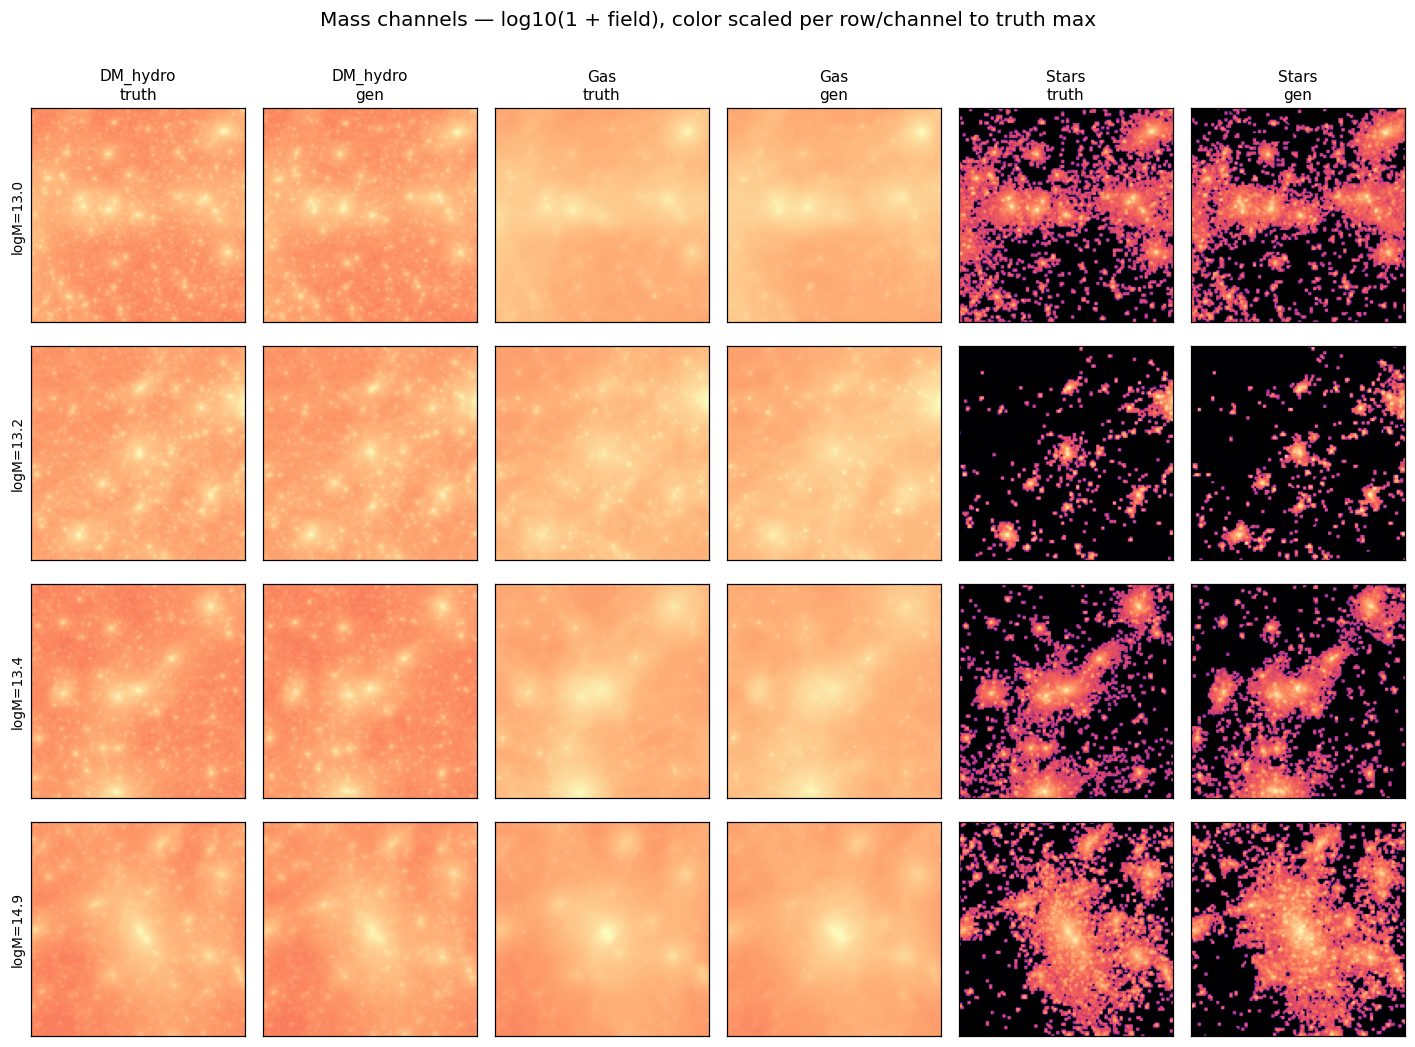

In [60]:
n_ex = 4
sel = np.argsort(halo_mass)[np.linspace(0, len(halo_mass) - 1, n_ex).astype(int)]
fig, axes = plt.subplots(n_ex, 6, figsize=(13, 2.4 * n_ex))
for r, idx in enumerate(sel):
    for c in range(3):
        t = np.log10(1 + mass_real[idx, c]); g = np.log10(1 + mass_gen[idx, c])
        vmax = max(t.max(), g.max(), 1e-3)
        for k, (img, tag) in enumerate([(t, 'truth'), (g, 'gen')]):
            ax = axes[r, 2 * c + k]
            ax.imshow(img, cmap='magma', origin='lower', vmin=0, vmax=vmax)
            ax.set_xticks([]); ax.set_yticks([])
            if r == 0:
                ax.set_title(f'{MASS_NAMES[c]}\n{tag}', fontsize=10)
    axes[r, 0].set_ylabel(f'logM={np.log10(halo_mass[idx]):.1f}', fontsize=9)
fig.suptitle('Mass channels — log10(1 + field), color scaled per row/channel to truth max', y=1.0)
plt.tight_layout(); plt.show()

## 2. Visual check — thermo channels
Log-scaled truth vs generated; color limits fixed to the truth 1–99% range per panel.

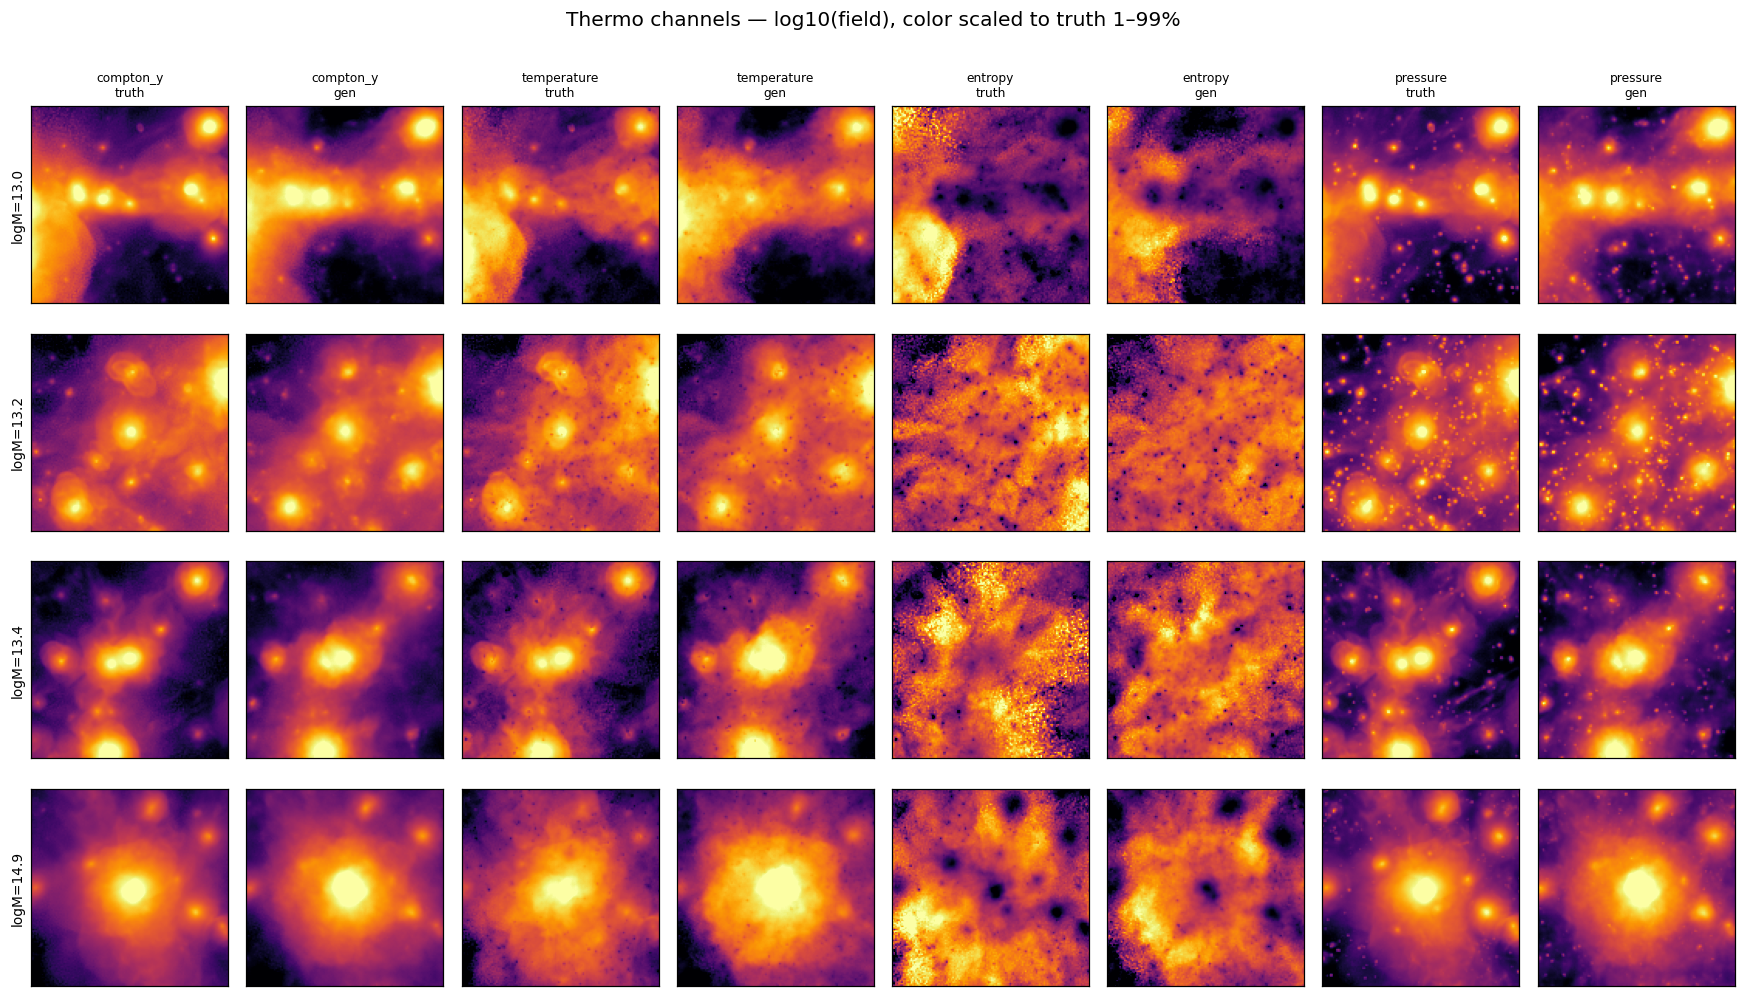

In [61]:
fig, axes = plt.subplots(n_ex, 2 * N_THERMO, figsize=(2.0 * 2 * N_THERMO, 2.3 * n_ex))
for r, idx in enumerate(sel):
    for c in range(N_THERMO):
        t = thermo_real[idx, c]; g = thermo_gen[idx, c]
        pos = t[t > 0]
        vmin, vmax = np.log10(np.percentile(pos, 1)), np.log10(np.percentile(pos, 99))
        for k, (arr, tag) in enumerate([(t, 'truth'), (g, 'gen')]):
            ax = axes[r, 2 * c + k]
            with np.errstate(divide='ignore'):
                img = np.log10(np.where(arr > 0, arr, np.nan))
            ax.imshow(img, cmap='inferno', origin='lower', vmin=vmin, vmax=vmax)
            ax.set_xticks([]); ax.set_yticks([])
            if r == 0:
                ax.set_title(f'{THERMO_NAMES[c]}\n{tag}', fontsize=8)
    axes[r, 0].set_ylabel(f'logM={np.log10(halo_mass[idx]):.1f}', fontsize=9)
fig.suptitle('Thermo channels — log10(field), color scaled to truth 1–99%', y=1.0)
plt.tight_layout(); plt.show()

## 3. Per-pixel thermo accuracy (dex)
Distribution of `log10(gen/truth)` over jointly-positive pixels — the test-suite metric. Red dashed line = median bias; σ = scatter.

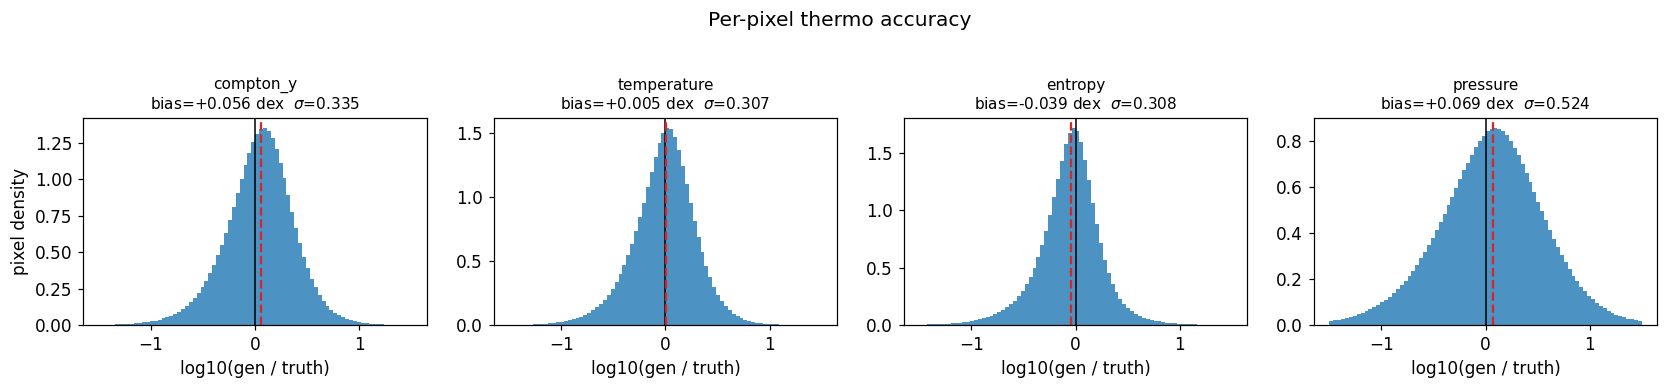

In [62]:
fig, axes = plt.subplots(1, N_THERMO, figsize=(3.8 * N_THERMO, 3.4))
thermo_stats = {}
for j, nm in enumerate(THERMO_NAMES):
    g = thermo_gen[:, j].ravel(); t = thermo_real[:, j].ravel()
    m = (g > 0) & (t > 0)
    d = np.log10(g[m]) - np.log10(t[m])
    bias, scat = float(np.median(d)), float(np.std(d))
    thermo_stats[nm] = dict(bias=bias, scatter=scat, n=int(m.sum()))
    ax = axes[j]
    ax.hist(d, bins=80, range=(-1.5, 1.5), color='tab:blue', alpha=0.8, density=True)
    ax.axvline(0, color='k', lw=1)
    ax.axvline(bias, color='tab:red', ls='--', lw=1.5)
    ax.set_title(f'{nm}\nbias={bias:+.3f} dex  $\\sigma$={scat:.3f}', fontsize=10)
    ax.set_xlabel('log10(gen / truth)')
axes[0].set_ylabel('pixel density')
fig.suptitle('Per-pixel thermo accuracy', y=1.03)
plt.tight_layout(); plt.show()

## 4. Thermo pixel-value distributions + KS
Marginal `log10(value)` distributions, truth vs generated. KS on a capped subsample.

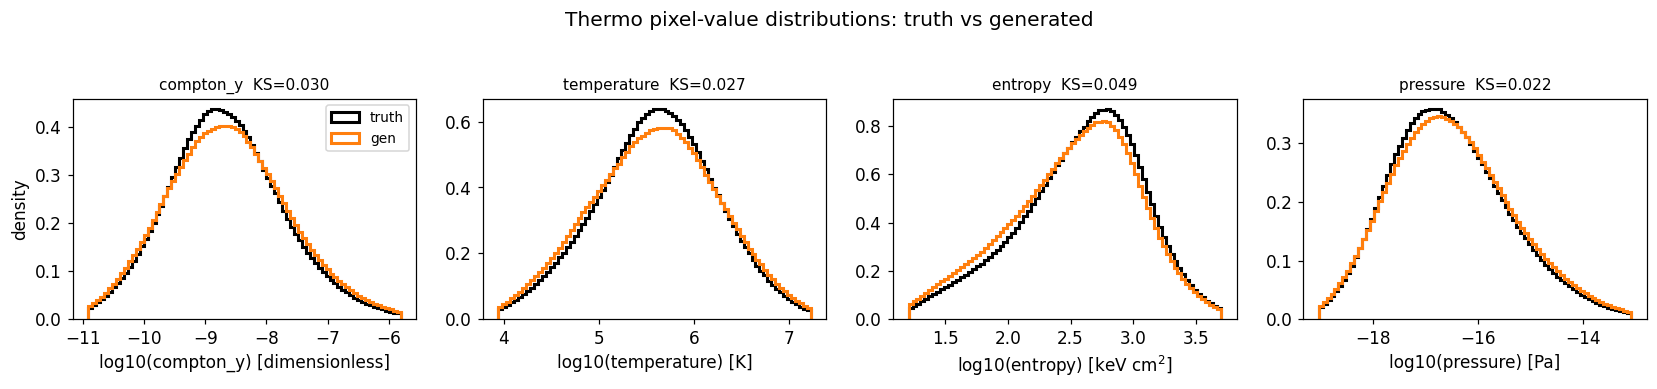

In [63]:
fig, axes = plt.subplots(1, N_THERMO, figsize=(3.8 * N_THERMO, 3.4))
ks_thermo = {}
for j, (nm, un) in enumerate(zip(THERMO_NAMES, THERMO_UNITS)):
    t = thermo_real[:, j].ravel(); g = thermo_gen[:, j].ravel()
    t = np.log10(t[t > 0]); g = np.log10(g[g > 0])
    lo, hi = np.percentile(np.concatenate([t, g]), [0.5, 99.5])
    bins = np.linspace(lo, hi, 80)
    ax = axes[j]
    ax.hist(t, bins=bins, density=True, histtype='step', lw=2, color='k', label='truth')
    ax.hist(g, bins=bins, density=True, histtype='step', lw=2, color='tab:orange', label='gen')
    n = min(len(t), len(g), 200_000)
    ks = stats.ks_2samp(np.random.choice(t, n), np.random.choice(g, n)).statistic
    ks_thermo[nm] = float(ks)
    ax.set_title(f'{nm}  KS={ks:.3f}', fontsize=10)
    ax.set_xlabel(f'log10({nm}) [{un}]')
axes[0].legend(fontsize=9); axes[0].set_ylabel('density')
fig.suptitle('Thermo pixel-value distributions: truth vs generated', y=1.03)
plt.tight_layout(); plt.show()

## 5. Thermo radial profiles
Median azimuthally-averaged profile per channel (centered cutout), with the 16–84% patch band.

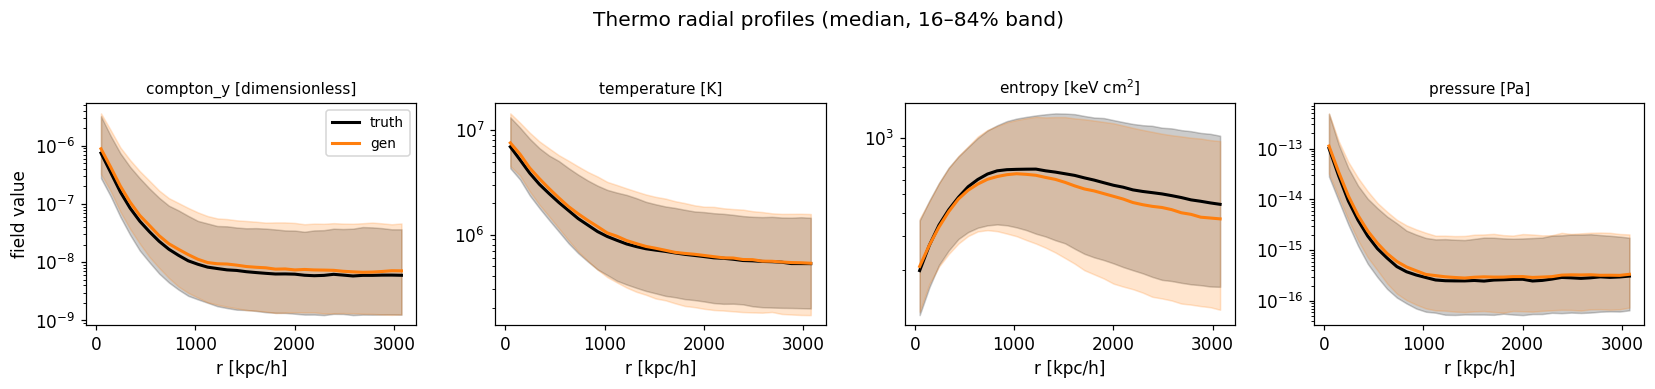

In [64]:
N_BINS = 32
fig, axes = plt.subplots(1, N_THERMO, figsize=(3.8 * N_THERMO, 3.4))
for j, (nm, un) in enumerate(zip(THERMO_NAMES, THERMO_UNITS)):
    pr_t, pr_g = [], []
    for i in range(len(thermo_real)):
        r, p = radial_profile(thermo_real[i, j], n_bins=N_BINS, logspace=False); pr_t.append(p)
        _, q = radial_profile(thermo_gen[i, j],  n_bins=N_BINS, logspace=False); pr_g.append(q)
    pr_t = np.asarray(pr_t); pr_g = np.asarray(pr_g)
    r_kpc = r * PIX_SIZE * 1e3               # pixels → kpc/h
    ax = axes[j]
    for arr, col, lab in [(pr_t, 'k', 'truth'), (pr_g, 'tab:orange', 'gen')]:
        med = np.median(arr, 0); lo, hi = np.percentile(arr, [16, 84], 0)
        ax.plot(r_kpc, med, color=col, lw=2, label=lab)
        ax.fill_between(r_kpc, lo, hi, color=col, alpha=0.2)
    ax.set_yscale('log'); ax.set_xlabel('r [kpc/h]')
    ax.set_title(f'{nm} [{un}]', fontsize=10)
axes[0].legend(fontsize=9); axes[0].set_ylabel('field value')
fig.suptitle('Thermo radial profiles (median, 16–84% band)', y=1.03)
plt.tight_layout(); plt.show()

## 6. Thermo amplitude vs halo mass
Patch-mean field value vs `log10(halo_mass)`, truth vs gen, with binned medians — does the model track the mass trend?

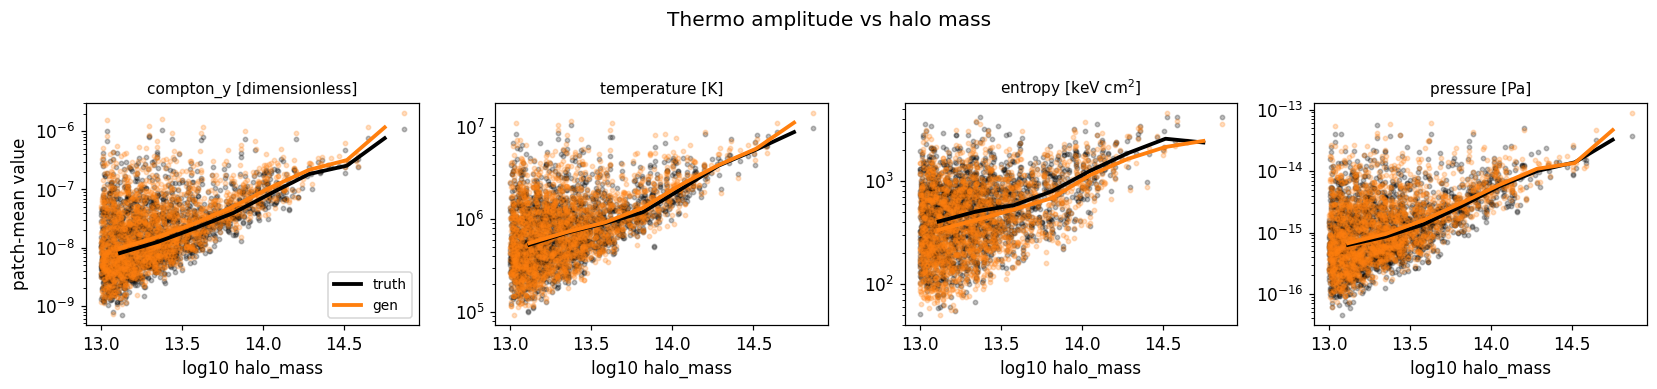

In [65]:
logM = np.log10(halo_mass)
mbins = np.linspace(np.nanmin(logM), np.nanmax(logM), 9)
mc = 0.5 * (mbins[:-1] + mbins[1:])

def binmed(vals):
    out = np.full(len(mc), np.nan)
    for b in range(len(mc)):
        s = (logM >= mbins[b]) & (logM < mbins[b + 1])
        if s.sum():
            out[b] = np.median(vals[s])
    return out

fig, axes = plt.subplots(1, N_THERMO, figsize=(3.8 * N_THERMO, 3.4))
for j, (nm, un) in enumerate(zip(THERMO_NAMES, THERMO_UNITS)):
    amp_t = thermo_real[:, j].mean(axis=(1, 2))
    amp_g = thermo_gen[:, j].mean(axis=(1, 2))
    ax = axes[j]
    ax.scatter(logM, amp_t, s=8, color='k', alpha=0.25)
    ax.scatter(logM, amp_g, s=8, color='tab:orange', alpha=0.25)
    ax.plot(mc, binmed(amp_t), color='k', lw=2.5, label='truth')
    ax.plot(mc, binmed(amp_g), color='tab:orange', lw=2.5, label='gen')
    ax.set_yscale('log'); ax.set_xlabel('log10 halo_mass')
    ax.set_title(f'{nm} [{un}]', fontsize=10)
axes[0].legend(fontsize=9); axes[0].set_ylabel('patch-mean value')
fig.suptitle('Thermo amplitude vs halo mass', y=1.03)
plt.tight_layout(); plt.show()

## 7. Mass-field regression check
Confirm the joint thermo objective did not degrade the mass channels: mean P(k) (truth vs gen) and pixel KS.


Computing power spectrum of the field...
Time to complete loop = 0.00
Time taken = 0.00 seconds

Computing power spectrum of the field...
Time to complete loop = 0.00
Time taken = 0.00 seconds

Computing power spectrum of the field...
Time to complete loop = 0.00
Time taken = 0.00 seconds

Computing power spectrum of the field...
Time to complete loop = 0.00
Time taken = 0.00 seconds

Computing power spectrum of the field...
Time to complete loop = 0.00
Time taken = 0.00 seconds

Computing power spectrum of the field...
Time to complete loop = 0.00
Time taken = 0.00 seconds

Computing power spectrum of the field...
Time to complete loop = 0.00
Time taken = 0.00 seconds

Computing power spectrum of the field...
Time to complete loop = 0.00
Time taken = 0.00 seconds

Computing power spectrum of the field...
Time to complete loop = 0.00
Time taken = 0.00 seconds

Computing power spectrum of the field...
Time to complete loop = 0.00
Time taken = 0.00 seconds

Computing power spectrum of t

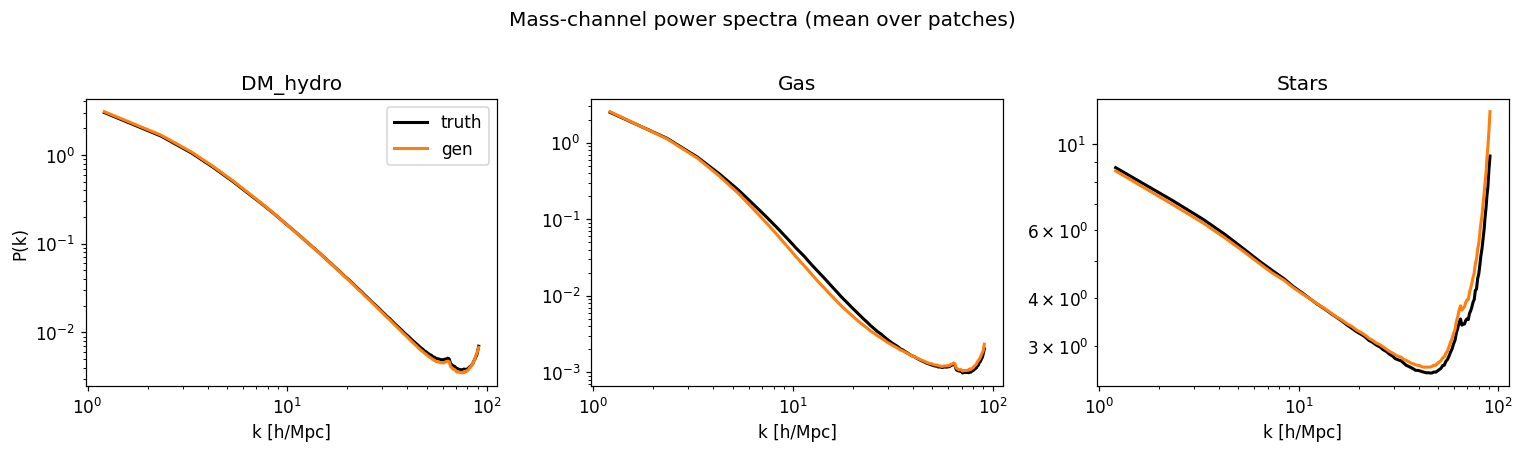

Mass-channel pixel KS (log10(1+x)): {'DM_hydro': 0.008, 'Gas': 0.06, 'Stars': 0.013}


In [66]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
ks_mass = {}
for c, nm in enumerate(MASS_NAMES):
    pk_t, pk_g, kref = [], [], None
    for i in range(len(mass_real)):
        if mass_real[i, c].sum() > 0 and mass_gen[i, c].sum() > 0:
            kref, p = power_spectrum_2d(mass_real[i, c] + 1e-8, box_size=BOX_SIZE); pk_t.append(p)
            _,    q = power_spectrum_2d(mass_gen[i, c]  + 1e-8, box_size=BOX_SIZE); pk_g.append(q)
    ax = axes[c]
    if pk_t:
        ax.loglog(kref, np.mean(pk_t, 0), 'k-',        lw=2, label='truth')
        ax.loglog(kref, np.mean(pk_g, 0), 'tab:orange', lw=2, label='gen')
    ax.set_title(nm); ax.set_xlabel('k [h/Mpc]')
    t = np.log10(1 + mass_real[:, c].ravel()); g = np.log10(1 + mass_gen[:, c].ravel())
    n = min(len(t), 200_000)
    ks_mass[nm] = float(stats.ks_2samp(np.random.choice(t, n), np.random.choice(g, n)).statistic)
axes[0].set_ylabel('P(k)'); axes[0].legend()
fig.suptitle('Mass-channel power spectra (mean over patches)', y=1.02)
plt.tight_layout(); plt.show()
print('Mass-channel pixel KS (log10(1+x)):', {k: round(v, 3) for k, v in ks_mass.items()})

## 8. Numeric scorecard

In [67]:
print('=' * 56)
print(f'{RUN_NAME} / {CKPT_NAME}  (epoch {epoch})  —  {len(real)} test patches')
print('=' * 56)
print(f'\n{"thermo channel":14s} {"KS":>7s} {"bias[dex]":>11s} {"scatter[dex]":>13s}')
print('-' * 48)
for nm in THERMO_NAMES:
    s = thermo_stats[nm]
    print(f'{nm:14s} {ks_thermo[nm]:7.3f} {s["bias"]:+11.3f} {s["scatter"]:13.3f}')
print('\nmass channel    KS (log10(1+x) pixels)')
print('-' * 38)
for nm in MASS_NAMES:
    print(f'{nm:14s} {ks_mass[nm]:7.3f}')

fm_thermo / last.ckpt  (epoch 8)  —  2048 test patches

thermo channel      KS   bias[dex]  scatter[dex]
------------------------------------------------
compton_y        0.030      +0.056         0.335
temperature      0.027      +0.005         0.307
entropy          0.049      -0.039         0.308
pressure         0.022      +0.069         0.524

mass channel    KS (log10(1+x) pixels)
--------------------------------------
DM_hydro         0.008
Gas              0.060
Stars            0.013


## 9. Scaling relations: Y-M, Y-T, T-M

Use simple patch-level summaries to probe thermodynamic scaling trends against halo mass:

- $Y_{\mathrm{int}} = \sum y\,\Delta A$ from the `compton_y` map (fixed pixel area $\Delta A$).
- $T_{\mathrm{mean}}$ = mean of positive-temperature pixels in each patch.

Then fit log-log relations of the form $\log_{10}(y)=a+b\log_{10}(x)$ for truth and generated maps.

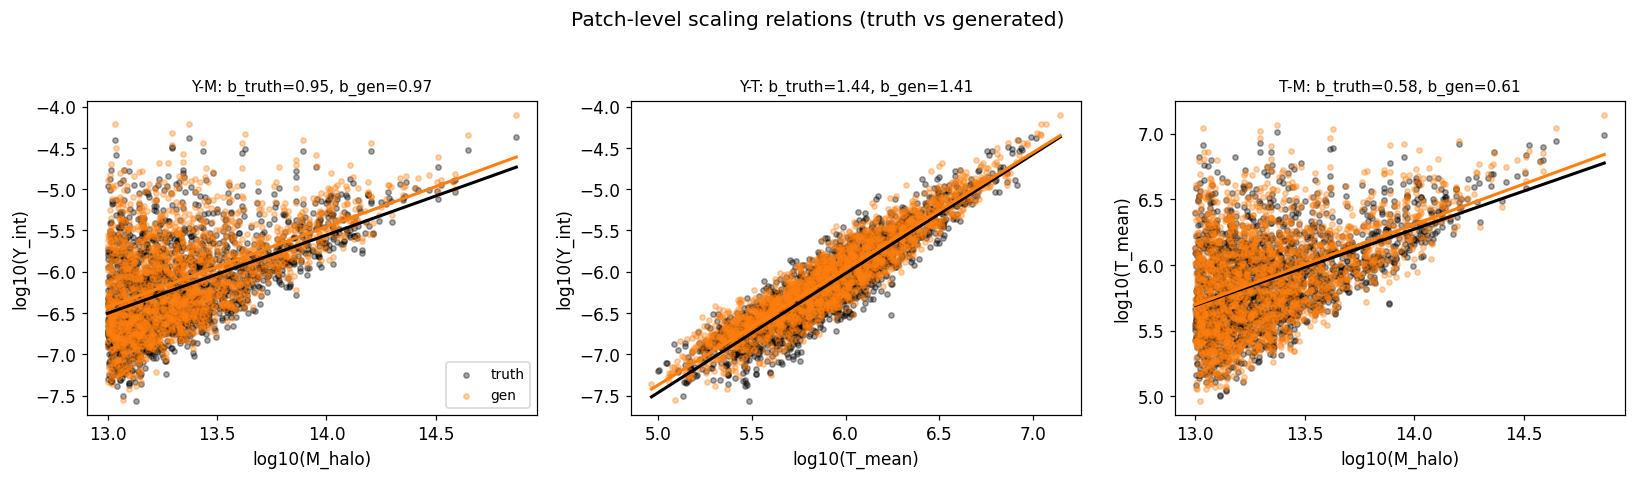

relation  slope_truth  slope_gen   r_truth   r_gen   n_truth   n_gen
----------------------------------------------------------------------------
Y-M            0.948      0.973     0.519   0.514      2048    2048
Y-T            1.445      1.410     0.916   0.936      2048    2048
T-M            0.581      0.612     0.501   0.487      2048    2048


In [68]:
iy = THERMO_NAMES.index('compton_y')
it = THERMO_NAMES.index('temperature')

def _patch_positive_mean(arr):
    out = np.full(arr.shape[0], np.nan, dtype=np.float64)
    for i in range(arr.shape[0]):
        m = arr[i] > 0
        if np.any(m):
            out[i] = arr[i][m].mean()
    return out

def _integrated_map(arr, pixel_size):
    return arr.sum(axis=(1, 2)) * (pixel_size ** 2)

def _fit_loglog(x, y):
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    if m.sum() < 3:
        return dict(mask=m, slope=np.nan, intercept=np.nan, r=np.nan, n=int(m.sum()))
    lx, ly = np.log10(x[m]), np.log10(y[m])
    r = stats.linregress(lx, ly)
    return dict(mask=m, slope=float(r.slope), intercept=float(r.intercept), r=float(r.rvalue), n=int(m.sum()))

Y_truth = _integrated_map(thermo_real[:, iy], PIX_SIZE)
Y_gen = _integrated_map(thermo_gen[:, iy], PIX_SIZE)
T_truth = _patch_positive_mean(thermo_real[:, it])
T_gen = _patch_positive_mean(thermo_gen[:, it])

relations = [
    ('Y-M', halo_mass, Y_truth, halo_mass, Y_gen, 'M_halo', 'Y_int'),
    ('Y-T', T_truth, Y_truth, T_gen, Y_gen, 'T_mean', 'Y_int'),
    ('T-M', halo_mass, T_truth, halo_mass, T_gen, 'M_halo', 'T_mean'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
rel_summary = {}
for ax, (name, x_t, y_t, x_g, y_g, xlab, ylab) in zip(axes, relations):
    fit_t = _fit_loglog(x_t, y_t)
    fit_g = _fit_loglog(x_g, y_g)

    mt, mg = fit_t['mask'], fit_g['mask']
    lxt, lyt = np.log10(x_t[mt]), np.log10(y_t[mt])
    lxg, lyg = np.log10(x_g[mg]), np.log10(y_g[mg])

    ax.scatter(lxt, lyt, s=12, alpha=0.35, color='k', label='truth')
    ax.scatter(lxg, lyg, s=12, alpha=0.35, color='tab:orange', label='gen')

    if np.isfinite(fit_t['slope']) and np.isfinite(fit_g['slope']):
        xmin = np.nanmin(np.concatenate([lxt, lxg]))
        xmax = np.nanmax(np.concatenate([lxt, lxg]))
        xx = np.linspace(xmin, xmax, 120)
        ax.plot(xx, fit_t['intercept'] + fit_t['slope'] * xx, color='k', lw=2.0)
        ax.plot(xx, fit_g['intercept'] + fit_g['slope'] * xx, color='tab:orange', lw=2.0)

    ax.set_xlabel(f'log10({xlab})')
    ax.set_ylabel(f'log10({ylab})')
    ax.set_title(f"{name}: b_truth={fit_t['slope']:.2f}, b_gen={fit_g['slope']:.2f}", fontsize=10)
    rel_summary[name] = dict(
        slope_truth=fit_t['slope'], slope_gen=fit_g['slope'],
        r_truth=fit_t['r'], r_gen=fit_g['r'],
        n_truth=fit_t['n'], n_gen=fit_g['n']
    )

axes[0].legend(fontsize=9)
fig.suptitle('Patch-level scaling relations (truth vs generated)', y=1.03)
plt.tight_layout(); plt.show()

print('relation  slope_truth  slope_gen   r_truth   r_gen   n_truth   n_gen')
print('-' * 76)
for name in ['Y-M', 'Y-T', 'T-M']:
    s = rel_summary[name]
    print(f"{name:8s} {s['slope_truth']:11.3f} {s['slope_gen']:10.3f} "
          f"{s['r_truth']:9.3f} {s['r_gen']:7.3f} {s['n_truth']:9d} {s['n_gen']:7d}")

## 10. Ideal-gas consistency check: $P \propto nT$

With projected maps, we do not have a direct number density $n$, so use gas-map amplitude as a proxy.
This tests proportionality rather than absolute calibration:

$$
P \propto (\mathrm{Gas})\,T
$$

We fit $\log_{10} P = a + b\,\log_{10}(\mathrm{Gas}\times T)$ on valid pixels for truth and generated maps.

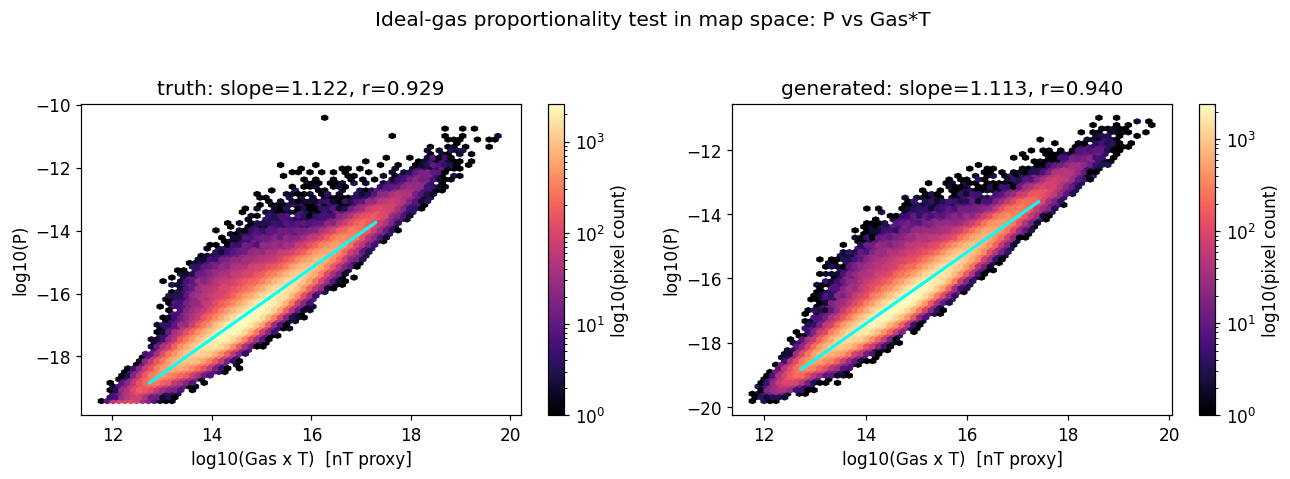

log10 P = a + b log10(Gas*T) fit summary
--------------------------------------------------------------
truth    : b=1.122, r=0.929, sigma_resid=0.429, n=400000
generated: b=1.113, r=0.940, sigma_resid=0.407, n=400000

effective proportionality constant kappa = P/(Gas*T)
truth    median=4.133e-32, IQR=[2.327e-32, 8.054e-32]
generated median=4.240e-32, IQR=[2.475e-32, 8.043e-32]


In [69]:
ig = MASS_NAMES.index('Gas')
ip = THERMO_NAMES.index('pressure')
it = THERMO_NAMES.index('temperature')

def _sample_px_relation(gas_map, temp_map, pres_map, max_points=400_000, seed=0):
    m = (gas_map > 0) & (temp_map > 0) & (pres_map > 0)
    x = (gas_map * temp_map)[m]
    y = pres_map[m]
    if x.size > max_points:
        rng = np.random.default_rng(seed)
        idx = rng.choice(x.size, size=max_points, replace=False)
        x, y = x[idx], y[idx]
    return x, y

def _fit_log_relation(x, y):
    lx, ly = np.log10(x), np.log10(y)
    fit = stats.linregress(lx, ly)
    model = fit.intercept + fit.slope * lx
    resid = ly - model
    return dict(
        slope=float(fit.slope), intercept=float(fit.intercept), r=float(fit.rvalue),
        scatter=float(np.std(resid)), n=int(len(x))
    )

gas_truth, gas_gen = mass_real[:, ig], mass_gen[:, ig]
Tmap_truth, Tmap_gen = thermo_real[:, it], thermo_gen[:, it]
Pmap_truth, Pmap_gen = thermo_real[:, ip], thermo_gen[:, ip]

x_t, y_t = _sample_px_relation(gas_truth, Tmap_truth, Pmap_truth, seed=11)
x_g, y_g = _sample_px_relation(gas_gen, Tmap_gen, Pmap_gen, seed=12)

fit_t = _fit_log_relation(x_t, y_t)
fit_g = _fit_log_relation(x_g, y_g)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, x, y, fit, ttl in [
    (axes[0], x_t, y_t, fit_t, 'truth'),
    (axes[1], x_g, y_g, fit_g, 'generated'),
]:
    lx, ly = np.log10(x), np.log10(y)
    hb = ax.hexbin(lx, ly, gridsize=68, bins='log', mincnt=1, cmap='magma')
    xx = np.linspace(np.percentile(lx, 1), np.percentile(lx, 99), 120)
    ax.plot(xx, fit['intercept'] + fit['slope'] * xx, color='cyan', lw=2.0)
    ax.set_xlabel('log10(Gas x T)  [nT proxy]')
    ax.set_ylabel('log10(P)')
    ax.set_title(f"{ttl}: slope={fit['slope']:.3f}, r={fit['r']:.3f}")
    cb = fig.colorbar(hb, ax=ax)
    cb.set_label('log10(pixel count)')

fig.suptitle('Ideal-gas proportionality test in map space: P vs Gas*T', y=1.03)
plt.tight_layout(); plt.show()

kappa_t = y_t / x_t
kappa_g = y_g / x_g
print('log10 P = a + b log10(Gas*T) fit summary')
print('-' * 62)
print(f"truth    : b={fit_t['slope']:.3f}, r={fit_t['r']:.3f}, sigma_resid={fit_t['scatter']:.3f}, n={fit_t['n']}")
print(f"generated: b={fit_g['slope']:.3f}, r={fit_g['r']:.3f}, sigma_resid={fit_g['scatter']:.3f}, n={fit_g['n']}")
print('')
print('effective proportionality constant kappa = P/(Gas*T)')
print(f"truth    median={np.median(kappa_t):.3e}, IQR=[{np.percentile(kappa_t,25):.3e}, {np.percentile(kappa_t,75):.3e}]")
print(f"generated median={np.median(kappa_g):.3e}, IQR=[{np.percentile(kappa_g,25):.3e}, {np.percentile(kappa_g,75):.3e}]")

## 11. Parameter sensitivity (35D) via Spearman rank correlation

To test whether the emulator captures *how outputs vary with input parameters*, compute Spearman correlations between each input parameter and patch-level observables.

For each observable (truth and generated separately), we report:

- $\rho_j = \mathrm{Spearman}(\theta_j,\, \mathrm{observable})$ for parameter $j=1..35$
- a heatmap over all parameters
- top-ranked parameters for $Y$, $T$, and $P$
- a truth-vs-generated sensitivity match score across parameters

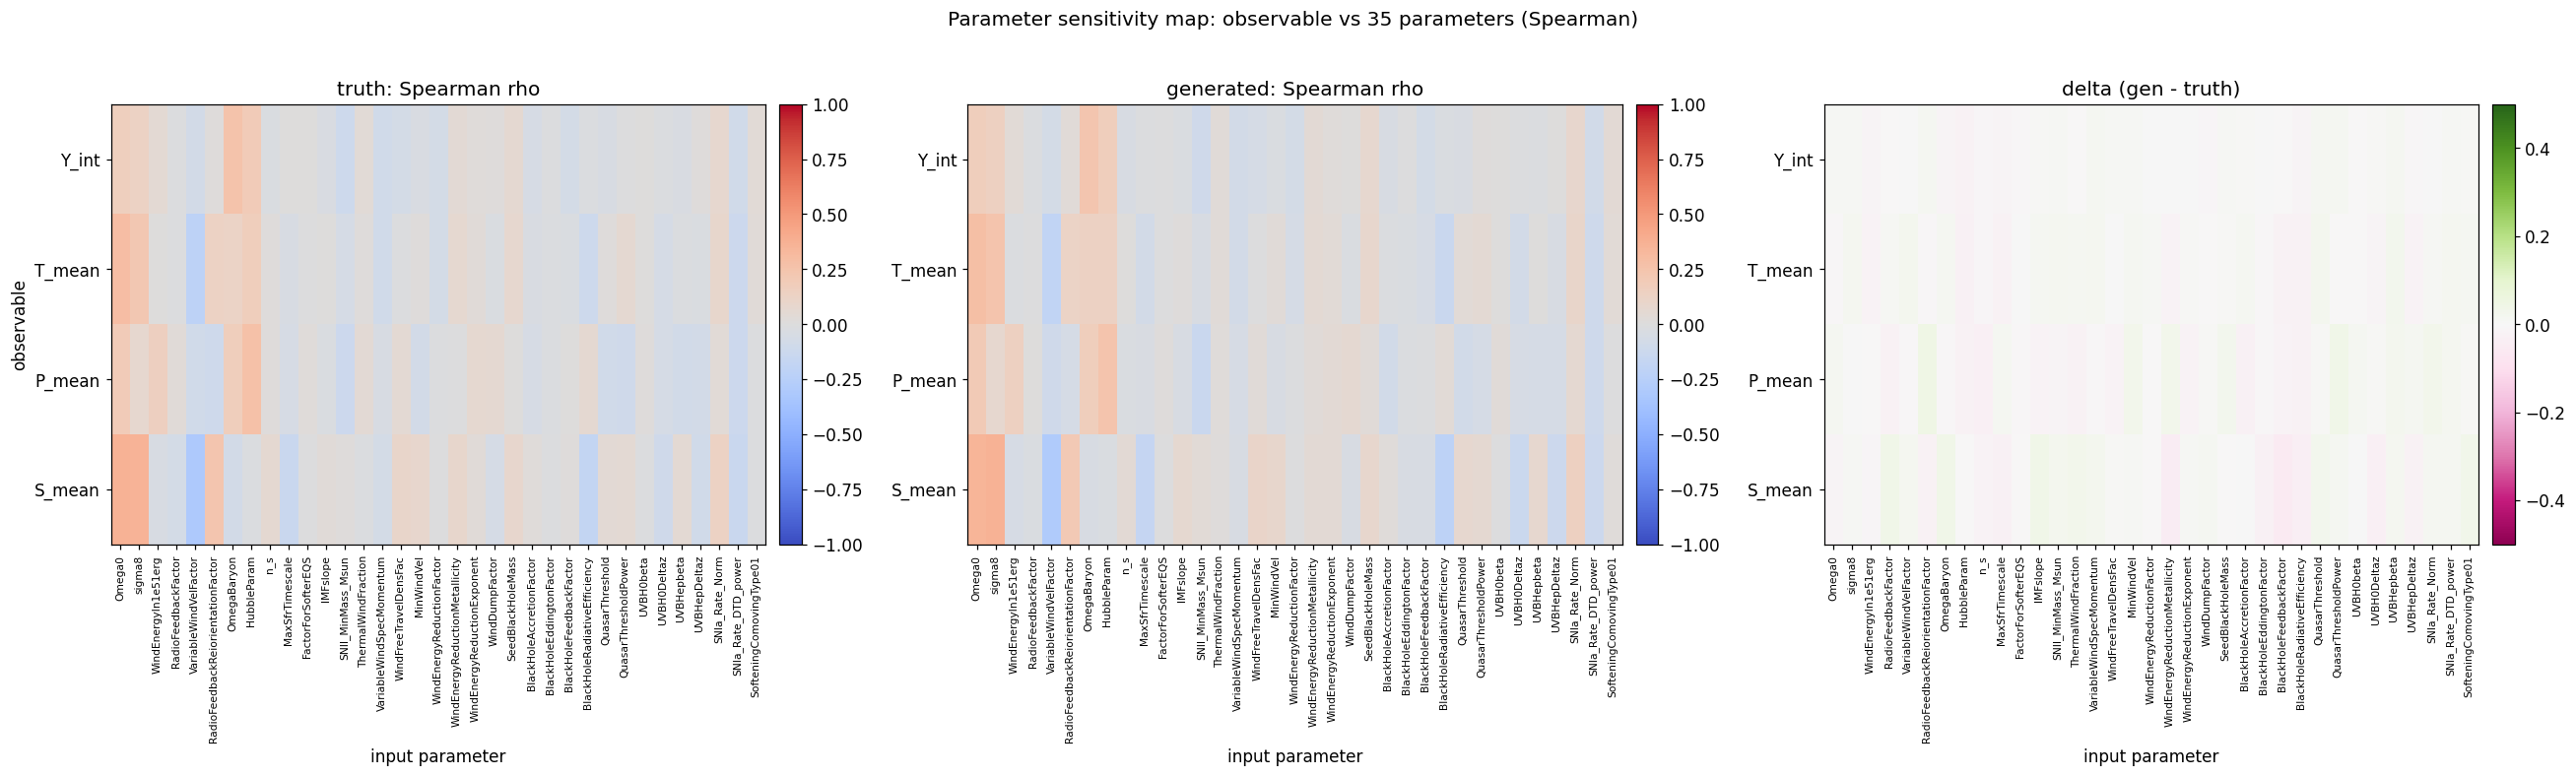

Observable sensitivity agreement across parameters
observable   rho(match)   mean|Δrho|   sig_truth(p<0.05)   sig_gen(p<0.05)
--------------------------------------------------------------------------------------
Y_int            0.985       0.008                   17                15
T_mean           0.979       0.013                   17                18
P_mean           0.956       0.017                   22                20
S_mean           0.958       0.020                   23                20


In [70]:
import csv
from bind.data import SB35_CSV

def _load_param_meta(path, n_expected):
    names, log_flags = [], []
    try:
        with open(path) as f:
            reader = csv.DictReader(f)
            for row in reader:
                names.append(row.get('ParamName', f'p{len(names):02d}'))
                log_flags.append(int(float(row.get('LogFlag', 0))))
    except Exception as e:
        print(f'Warning: could not read parameter metadata from {path}: {e}')
        names = [f'p{i:02d}' for i in range(n_expected)]
        log_flags = [0] * n_expected

    if len(names) != n_expected:
        print(f'Warning: metadata has {len(names)} params, but data has {n_expected}; using fallback names.')
        names = [f'p{i:02d}' for i in range(n_expected)]
        log_flags = [0] * n_expected
    return names, np.asarray(log_flags, dtype=np.int32)

def _safe_positive_mean(arr):
    out = np.full(arr.shape[0], np.nan, dtype=np.float64)
    for i in range(arr.shape[0]):
        m = arr[i] > 0
        if np.any(m):
            out[i] = arr[i][m].mean()
    return out

def _safe_integrated(arr, pixel_size):
    return arr.sum(axis=(1, 2)) * (pixel_size ** 2)

def _spearman_vector(X, y):
    rho = np.full(X.shape[1], np.nan, dtype=np.float64)
    pval = np.full(X.shape[1], np.nan, dtype=np.float64)
    my = np.isfinite(y)
    for j in range(X.shape[1]):
        m = my & np.isfinite(X[:, j])
        if m.sum() >= 6:
            res = stats.spearmanr(X[m, j], y[m])
            rho[j] = float(res.correlation)
            pval[j] = float(res.pvalue)
    return rho, pval

def _corr_of_vectors(a, b):
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan
    return float(stats.spearmanr(a[m], b[m]).correlation)

n_params = params.shape[1]
param_names, param_log_flag = _load_param_meta(SB35_CSV, n_params)

# Spearman is rank-based, so using normalized params is valid (monotonic transforms
# preserve rank ordering).
X = params.astype(np.float64)

iy = THERMO_NAMES.index('compton_y')
it = THERMO_NAMES.index('temperature')
ip = THERMO_NAMES.index('pressure')
ie = THERMO_NAMES.index('entropy')

obs_truth = {
    'Y_int': _safe_integrated(thermo_real[:, iy], PIX_SIZE),
    'T_mean': _safe_positive_mean(thermo_real[:, it]),
    'P_mean': _safe_positive_mean(thermo_real[:, ip]),
    'S_mean': _safe_positive_mean(thermo_real[:, ie]),
}
obs_gen = {
    'Y_int': _safe_integrated(thermo_gen[:, iy], PIX_SIZE),
    'T_mean': _safe_positive_mean(thermo_gen[:, it]),
    'P_mean': _safe_positive_mean(thermo_gen[:, ip]),
    'S_mean': _safe_positive_mean(thermo_gen[:, ie]),
}

obs_names = list(obs_truth.keys())
rho_truth, p_truth = [], []
rho_gen, p_gen = [], []
for nm in obs_names:
    r_t, pv_t = _spearman_vector(X, obs_truth[nm])
    r_g, pv_g = _spearman_vector(X, obs_gen[nm])
    rho_truth.append(r_t); p_truth.append(pv_t)
    rho_gen.append(r_g); p_gen.append(pv_g)
rho_truth = np.vstack(rho_truth)
p_truth = np.vstack(p_truth)
rho_gen = np.vstack(rho_gen)
p_gen = np.vstack(p_gen)

fig, axes = plt.subplots(1, 3, figsize=(24, 7), gridspec_kw={'width_ratios': [1, 1, 1]})
im0 = axes[0].imshow(rho_truth, vmin=-1, vmax=1, cmap='coolwarm', aspect='auto')
im1 = axes[1].imshow(rho_gen, vmin=-1, vmax=1, cmap='coolwarm', aspect='auto')
im2 = axes[2].imshow(rho_gen - rho_truth, vmin=-0.5, vmax=0.5, cmap='PiYG', aspect='auto')

for ax, ttl in zip(axes, ['truth: Spearman rho', 'generated: Spearman rho', 'delta (gen - truth)']):
    ax.set_xticks(np.arange(n_params))
    ax.set_xticklabels(param_names, rotation=90, fontsize=7)
    ax.set_yticks(np.arange(len(obs_names)))
    ax.set_yticklabels(obs_names)
    ax.set_xlabel('input parameter')
    ax.set_title(ttl)
axes[0].set_ylabel('observable')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.02)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.02)
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.02)
fig.suptitle('Parameter sensitivity map: observable vs 35 parameters (Spearman)', y=1.02)
plt.tight_layout(); plt.show()

print('Observable sensitivity agreement across parameters')
print('observable   rho(match)   mean|Δrho|   sig_truth(p<0.05)   sig_gen(p<0.05)')
print('-' * 86)
for i, nm in enumerate(obs_names):
    match = _corr_of_vectors(rho_truth[i], rho_gen[i])
    m = np.isfinite(rho_truth[i]) & np.isfinite(rho_gen[i])
    mad = float(np.mean(np.abs(rho_gen[i, m] - rho_truth[i, m]))) if np.any(m) else np.nan
    sig_t = int(np.sum((p_truth[i] < 0.05) & m))
    sig_g = int(np.sum((p_gen[i] < 0.05) & m))
    print(f'{nm:10s} {match:11.3f} {mad:11.3f} {sig_t:20d} {sig_g:17d}')

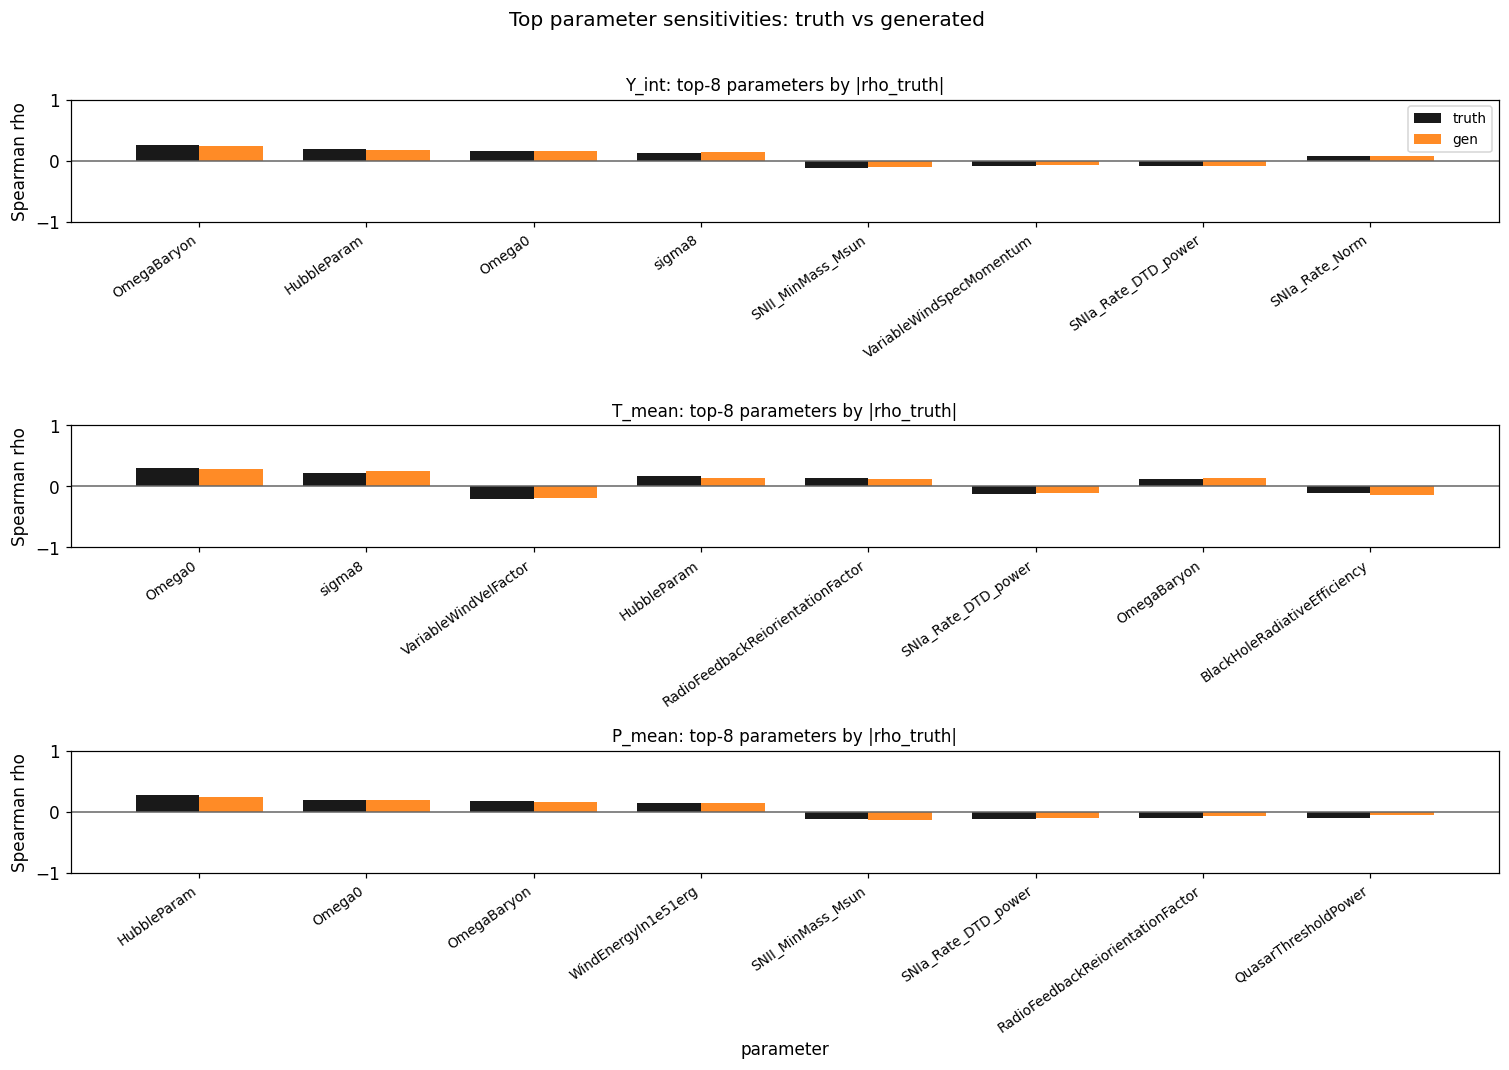

Top-5 parameters by |rho_truth| for each focus observable
------------------------------------------------------------------------
Y_int  : OmegaBaryon (+0.25->+0.24), HubbleParam (+0.19->+0.17), Omega0 (+0.16->+0.16), sigma8 (+0.13->+0.14), SNII_MinMass_Msun (-0.11->-0.10)
T_mean : Omega0 (+0.29->+0.29), sigma8 (+0.22->+0.24), VariableWindVelFactor (-0.22->-0.19), HubbleParam (+0.17->+0.14), RadioFeedbackReiorientationFactor (+0.13->+0.12)
P_mean : HubbleParam (+0.27->+0.25), Omega0 (+0.19->+0.20), OmegaBaryon (+0.17->+0.16), WindEnergyIn1e51erg (+0.15->+0.15), SNII_MinMass_Msun (-0.12->-0.14)


In [71]:
TOPK = 8
focus_obs = ['Y_int', 'T_mean', 'P_mean']
fig, axes = plt.subplots(len(focus_obs), 1, figsize=(14, 3.2 * len(focus_obs)))
if len(focus_obs) == 1:
    axes = [axes]

for ax, nm in zip(axes, focus_obs):
    i = obs_names.index(nm)
    score = np.abs(rho_truth[i])
    score = np.where(np.isfinite(score), score, -1)
    order = np.argsort(score)[-TOPK:][::-1]

    x = np.arange(TOPK)
    w = 0.38
    ax.bar(x - w / 2, rho_truth[i, order], width=w, color='k', alpha=0.9, label='truth')
    ax.bar(x + w / 2, rho_gen[i, order], width=w, color='tab:orange', alpha=0.9, label='gen')
    ax.axhline(0, color='0.4', lw=1)
    ax.set_ylim(-1.0, 1.0)
    ax.set_ylabel('Spearman rho')
    ax.set_title(f'{nm}: top-{TOPK} parameters by |rho_truth|', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels([param_names[j] for j in order], rotation=35, ha='right', fontsize=9)

axes[0].legend(loc='upper right', fontsize=9)
axes[-1].set_xlabel('parameter')
fig.suptitle('Top parameter sensitivities: truth vs generated', y=1.01)
plt.tight_layout(); plt.show()

print('Top-5 parameters by |rho_truth| for each focus observable')
print('-' * 72)
for nm in focus_obs:
    i = obs_names.index(nm)
    order = np.argsort(np.abs(rho_truth[i]))[::-1][:5]
    txt = ', '.join([f'{param_names[j]} ({rho_truth[i, j]:+.2f}->{rho_gen[i, j]:+.2f})' for j in order])
    print(f'{nm:7s}: {txt}')

## 12. Deviation from self-similarity (R200 aperture, per-halo cosmology)

Compute thermo observables inside a per-halo $R_{200}$ aperture using each halo's cosmology from the 35-parameter vector.
We first denormalize parameters to recover physical $\Omega_m$ and $\Omega_b$, then use

$$
R_{200} = \left(\frac{3M_{200}}{4\pi\,200\,\rho_m}\right)^{1/3},\quad \rho_m = \Omega_m\rho_{\rm crit}.
$$

To remove first-order baryon-content scaling, normalize pressure-related observables by the baryon fraction

$$
f_b = \Omega_b / \Omega_m, \qquad Y \rightarrow Y/f_b, \quad P \rightarrow P/f_b.
$$

Self-similar reference slopes at fixed redshift (for the normalized observables):

- $Y(<R_{200})/f_b \propto M^{5/3}$
- $T(<R_{200}) \propto M^{2/3}$
- $P(<R_{200})/f_b \propto M^{2/3}$

We compare truth and generated trends against these expectations and inspect

$$
\Delta\log_{10} O = \log_{10} O - \left[a_{\rm ss} + \alpha_{\rm ss}\log_{10} M\right].
$$

Omega_m range: [0.101, 0.500]
Omega_b range: [0.029, 0.069]
f_b=Omega_b/Omega_m range: [0.061, 0.682] | median=0.135
R200 range: 9.1 - 38.3 pix  (0.45 - 1.87 Mpc/h)
R200 median: 12.7 pix = 0.62 Mpc/h


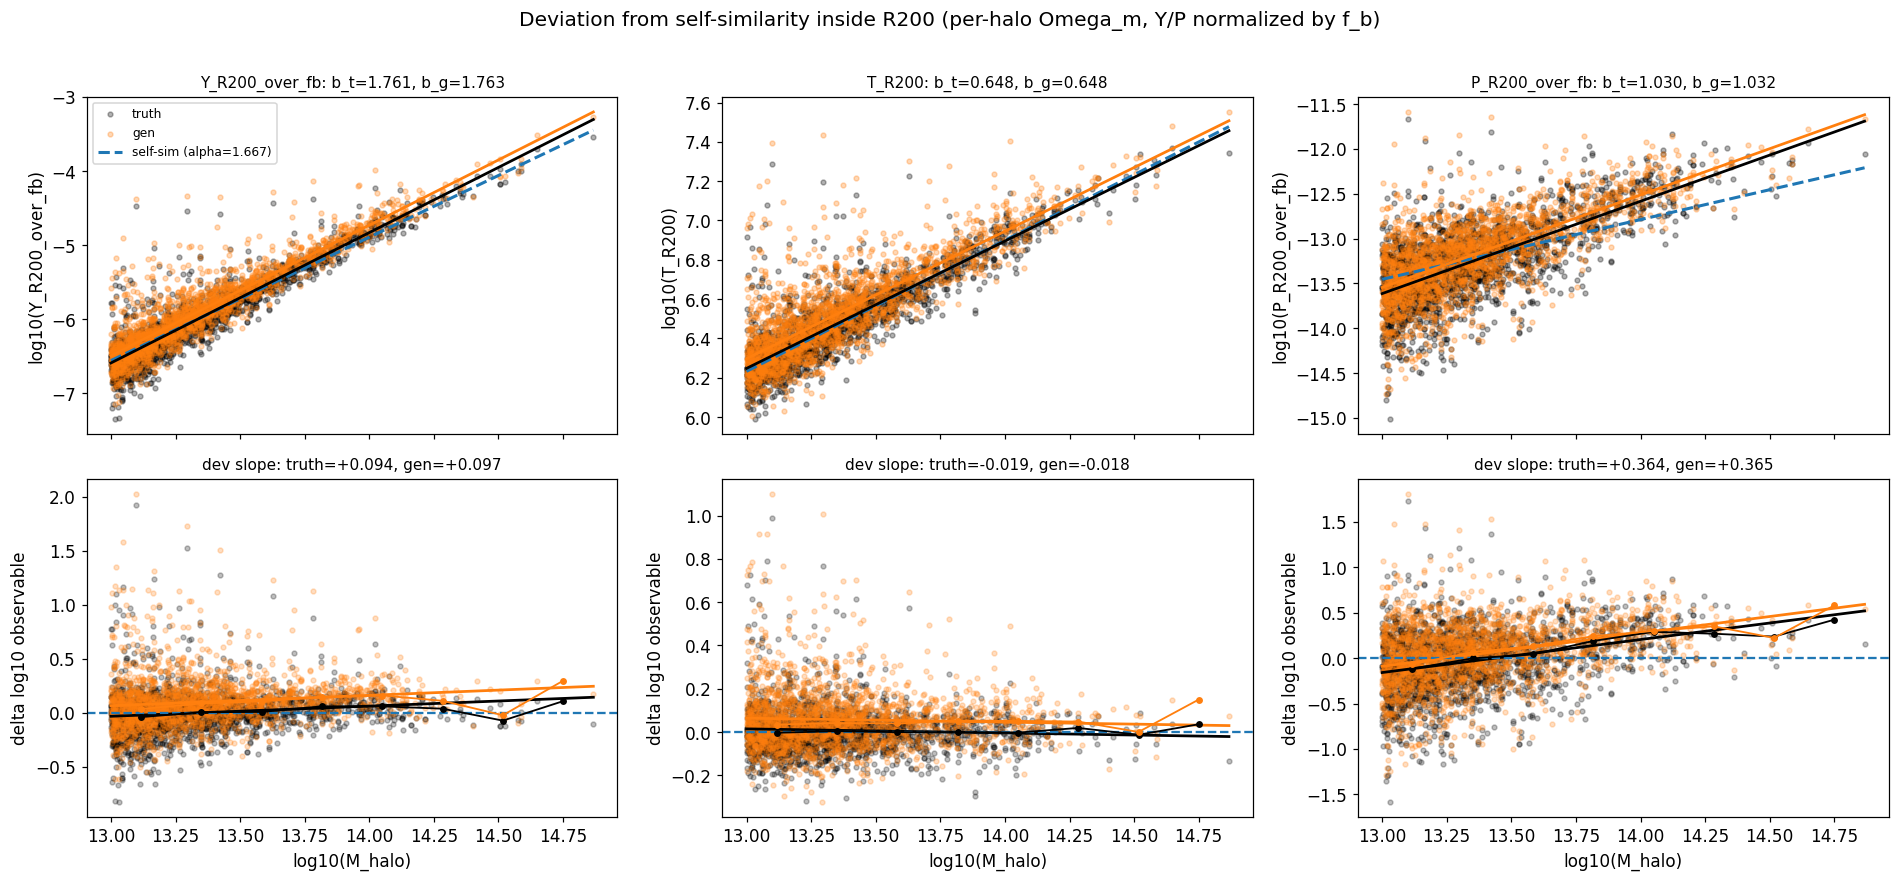

observable         alpha_ss   b_truth   b_gen   (b-a)_truth   (b-a)_gen   rms_dev_t   rms_dev_g
--------------------------------------------------------------------------------------------------------------------
Y_R200_over_fb       1.667     1.761    1.763         0.094       0.097       0.209       0.232
T_R200               0.667     0.648    0.648        -0.019      -0.018       0.109       0.138
P_R200_over_fb       0.667     1.030    1.032         0.364       0.365       0.352       0.348


In [72]:
import csv
from bind.data import SB35_CSV

def _fit_loglog_basic(x, y):
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    if m.sum() < 6:
        return dict(mask=m, lx=np.array([]), ly=np.array([]), slope=np.nan, intercept=np.nan, r=np.nan)
    lx = np.log10(x[m])
    ly = np.log10(y[m])
    fit = stats.linregress(lx, ly)
    return dict(mask=m, lx=lx, ly=ly, slope=float(fit.slope), intercept=float(fit.intercept), r=float(fit.rvalue))

def _binned_median(x, y, n_bins=9):
    bins = np.linspace(np.nanmin(x), np.nanmax(x), n_bins + 1)
    xc = 0.5 * (bins[:-1] + bins[1:])
    med = np.full(n_bins, np.nan)
    for i in range(n_bins):
        m = (x >= bins[i]) & (x < bins[i + 1])
        if np.any(m):
            med[i] = np.median(y[m])
    return xc, med

def _load_param_names(path, n_expected):
    try:
        with open(path) as f:
            names = [row['ParamName'] for row in csv.DictReader(f)]
    except Exception:
        names = [f'p{i:02d}' for i in range(n_expected)]
    if len(names) != n_expected:
        names = [f'p{i:02d}' for i in range(n_expected)]
    return names

def denormalize_params(params_norm, ns_obj):
    """Invert dataset parameter normalization back to physical parameter values."""
    p = np.asarray(params_norm, dtype=np.float64)
    p01 = p * (ns_obj.param_max[None, :] - ns_obj.param_min[None, :]) + ns_obj.param_min[None, :]
    raw = p01.copy()
    log_mask = np.asarray(ns_obj.param_log_flag == 1, dtype=bool)
    if np.any(log_mask):
        raw[:, log_mask] = np.power(10.0, p01[:, log_mask])
    return raw

def compute_r200_pix(halo_masses_msun_h, pix_size_mpc_h, omega_m_arr):
    """R200 in patch pixels from halo mass [M_sun/h] and per-halo Omega_m."""
    rho_c = 2.77536627e11  # h^2 M_sun / Mpc^3
    om = np.asarray(omega_m_arr, dtype=np.float64)
    om = np.where(np.isfinite(om) & (om > 0), om, np.nan)
    rho_m = om * rho_c
    m200 = np.asarray(halo_masses_msun_h, dtype=np.float64)
    r200_mpc_h = np.power(3.0 * m200 / (4.0 * np.pi * 200.0 * rho_m), 1.0 / 3.0)
    return r200_mpc_h / pix_size_mpc_h

def aperture_integrated_batch(maps, r_pix, pix_size_mpc_h):
    """Integrated quantity inside circular aperture of radius r_pix per halo."""
    n, h, w = maps.shape
    yy, xx = np.indices((h, w))
    cy, cx = 0.5 * (h - 1), 0.5 * (w - 1)
    d2 = (yy - cy) ** 2 + (xx - cx) ** 2
    out = np.full(n, np.nan, dtype=np.float64)
    for i in range(n):
        rp = r_pix[i]
        if not np.isfinite(rp) or rp <= 0:
            continue
        m = d2 <= (rp ** 2)
        out[i] = maps[i][m].sum() * (pix_size_mpc_h ** 2)
    return out

def aperture_positive_mean_batch(maps, r_pix):
    """Mean of positive pixels inside circular aperture of radius r_pix per halo."""
    n, h, w = maps.shape
    yy, xx = np.indices((h, w))
    cy, cx = 0.5 * (h - 1), 0.5 * (w - 1)
    d2 = (yy - cy) ** 2 + (xx - cx) ** 2
    out = np.full(n, np.nan, dtype=np.float64)
    for i in range(n):
        rp = r_pix[i]
        if not np.isfinite(rp) or rp <= 0:
            continue
        m = d2 <= (rp ** 2)
        vals = maps[i][m]
        pos = vals[vals > 0]
        if pos.size:
            out[i] = pos.mean()
    return out

# Recover per-halo Omega_m / Omega_b from normalized params.
param_raw = denormalize_params(params, ns)
param_names_local = _load_param_names(SB35_CSV, param_raw.shape[1])
idx_om = param_names_local.index('Omega0') if 'Omega0' in param_names_local else 0
idx_ob = param_names_local.index('OmegaBaryon') if 'OmegaBaryon' in param_names_local else 6

omega_m_halo = param_raw[:, idx_om]
omega_b_halo = param_raw[:, idx_ob]
fb_halo = omega_b_halo / np.maximum(omega_m_halo, 1e-12)
fb_halo = np.where(np.isfinite(fb_halo) & (fb_halo > 0), fb_halo, np.nan)

print(f'Omega_m range: [{np.nanmin(omega_m_halo):.3f}, {np.nanmax(omega_m_halo):.3f}]')
print(f'Omega_b range: [{np.nanmin(omega_b_halo):.3f}, {np.nanmax(omega_b_halo):.3f}]')
print(f'f_b=Omega_b/Omega_m range: [{np.nanmin(fb_halo):.3f}, {np.nanmax(fb_halo):.3f}] | median={np.nanmedian(fb_halo):.3f}')

# Patch-level observables inside per-halo R200 aperture.
iy = THERMO_NAMES.index('compton_y')
it = THERMO_NAMES.index('temperature')
ip = THERMO_NAMES.index('pressure')

r200_pix = compute_r200_pix(halo_mass, PIX_SIZE, omega_m_halo)
print(f'R200 range: {np.nanmin(r200_pix):.1f} - {np.nanmax(r200_pix):.1f} pix  '
      f'({np.nanmin(r200_pix) * PIX_SIZE:.2f} - {np.nanmax(r200_pix) * PIX_SIZE:.2f} Mpc/h)')
print(f'R200 median: {np.nanmedian(r200_pix):.1f} pix = {np.nanmedian(r200_pix) * PIX_SIZE:.2f} Mpc/h')

Y_t_raw = aperture_integrated_batch(thermo_real[:, iy], r200_pix, PIX_SIZE)
Y_g_raw = aperture_integrated_batch(thermo_gen[:, iy], r200_pix, PIX_SIZE)
T_t = aperture_positive_mean_batch(thermo_real[:, it], r200_pix)
T_g = aperture_positive_mean_batch(thermo_gen[:, it], r200_pix)
P_t_raw = aperture_positive_mean_batch(thermo_real[:, ip], r200_pix)
P_g_raw = aperture_positive_mean_batch(thermo_gen[:, ip], r200_pix)

# Baryon-fraction normalized observables (requested): Y/f_b and P/f_b.
Y_t = Y_t_raw / fb_halo
Y_g = Y_g_raw / fb_halo
P_t = P_t_raw / fb_halo
P_g = P_g_raw / fb_halo

ss_defs = [
    ('Y_R200_over_fb', Y_t, Y_g, 5.0 / 3.0),
    ('T_R200', T_t, T_g, 2.0 / 3.0),
    ('P_R200_over_fb', P_t, P_g, 2.0 / 3.0),
]

fig, axes = plt.subplots(2, len(ss_defs), figsize=(5.8 * len(ss_defs), 7.9), sharex='col')
ss_summary = {}

for j, (name, y_truth, y_gen, alpha_ss) in enumerate(ss_defs):
    ft = _fit_loglog_basic(halo_mass, y_truth)
    fg = _fit_loglog_basic(halo_mass, y_gen)

    lx_t, ly_t = ft['lx'], ft['ly']
    lx_g, ly_g = fg['lx'], fg['ly']
    if len(lx_t) == 0 or len(lx_g) == 0:
        continue

    # Truth-calibrated self-similar normalization for residuals.
    a_ss = float(np.median(ly_t - alpha_ss * lx_t))

    d_t = ly_t - (a_ss + alpha_ss * lx_t)
    d_g = ly_g - (a_ss + alpha_ss * lx_g)

    dt_fit = stats.linregress(lx_t, d_t)
    dg_fit = stats.linregress(lx_g, d_g)

    ax0, ax1 = axes[0, j], axes[1, j]
    ax0.scatter(lx_t, ly_t, s=10, alpha=0.30, color='k', label='truth')
    ax0.scatter(lx_g, ly_g, s=10, alpha=0.30, color='tab:orange', label='gen')

    xx = np.linspace(min(np.nanmin(lx_t), np.nanmin(lx_g)),
                     max(np.nanmax(lx_t), np.nanmax(lx_g)), 160)
    ax0.plot(xx, a_ss + alpha_ss * xx, color='tab:blue', lw=2.0, ls='--',
             label=f'self-sim (alpha={alpha_ss:.3f})')
    ax0.plot(xx, ft['intercept'] + ft['slope'] * xx, color='k', lw=1.8)
    ax0.plot(xx, fg['intercept'] + fg['slope'] * xx, color='tab:orange', lw=1.8)
    ax0.set_ylabel(f'log10({name})')
    ax0.set_title(f"{name}: b_t={ft['slope']:.3f}, b_g={fg['slope']:.3f}", fontsize=10)

    ax1.scatter(lx_t, d_t, s=10, alpha=0.25, color='k')
    ax1.scatter(lx_g, d_g, s=10, alpha=0.25, color='tab:orange')
    ax1.plot(xx, dt_fit.intercept + dt_fit.slope * xx, color='k', lw=1.8)
    ax1.plot(xx, dg_fit.intercept + dg_fit.slope * xx, color='tab:orange', lw=1.8)
    ax1.axhline(0, color='tab:blue', lw=1.5, ls='--')

    xc_t, med_t = _binned_median(lx_t, d_t, n_bins=8)
    xc_g, med_g = _binned_median(lx_g, d_g, n_bins=8)
    ax1.plot(xc_t, med_t, 'ko-', lw=1.2, ms=3.5)
    ax1.plot(xc_g, med_g, 'o-', color='tab:orange', lw=1.2, ms=3.5)

    ax1.set_xlabel('log10(M_halo)')
    ax1.set_ylabel('delta log10 observable')
    ax1.set_title(f"dev slope: truth={dt_fit.slope:+.3f}, gen={dg_fit.slope:+.3f}", fontsize=10)

    ss_summary[name] = dict(
        alpha_ss=float(alpha_ss),
        b_truth=ft['slope'],
        b_gen=fg['slope'],
        db_truth=float(ft['slope'] - alpha_ss),
        db_gen=float(fg['slope'] - alpha_ss),
        dev_slope_truth=float(dt_fit.slope),
        dev_slope_gen=float(dg_fit.slope),
        rms_dev_truth=float(np.std(d_t)),
        rms_dev_gen=float(np.std(d_g)),
    )

axes[0, 0].legend(fontsize=8, loc='best')
fig.suptitle('Deviation from self-similarity inside R200 (per-halo Omega_m, Y/P normalized by f_b)', y=1.01)
plt.tight_layout(); plt.show()

print('observable         alpha_ss   b_truth   b_gen   (b-a)_truth   (b-a)_gen   rms_dev_t   rms_dev_g')
print('-' * 116)
for nm in ['Y_R200_over_fb', 'T_R200', 'P_R200_over_fb']:
    s = ss_summary[nm]
    print(f"{nm:16s} {s['alpha_ss']:9.3f} {s['b_truth']:9.3f} {s['b_gen']:8.3f} "
          f"{s['db_truth']:13.3f} {s['db_gen']:11.3f} {s['rms_dev_truth']:11.3f} {s['rms_dev_gen']:11.3f}")